# Cell 1 - Install Dependencies

In [1]:
# =========================
# Cell 1 — Install Dependencies (FINAL)
# =========================

# scikeras TIDAK selalu ada di Kaggle → wajib install
!pip install -q scikeras
!pip install -q scikit-learn

# TensorFlow biasanya sudah ada, tapi ini aman kalau environment baru
!pip install -q tensorflow

# Visualisasi (biasanya sudah ada, tapi aman)
!pip install -q seaborn matplotlib


# Cell 2 - Imports & Setup (FINAL - RF, SVM, DNN)

In [2]:
# =========================
# Cell 2 - Imports & Setup (FINAL - RF, SVM, DNN)
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

# FORCE CPU BEFORE ANYTHING
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

# Menggunakan GridSearchCV dan StratifiedKFold untuk Cross-Validation Tuning
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.base import clone

# --- Keras/TensorFlow untuk DNN ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import LambdaCallback, EarlyStopping
from tensorflow.keras import regularizers

from xgboost import XGBClassifier

# FORCE CPU BEFORE ANYTHING
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

tf.get_logger().setLevel("ERROR")

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

print("🔇 CPU-only mode enforced")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Inisialisasi variabel global untuk hasil tuning
acc_svm_mrmr = np.nan; best_params_svm_mrmr = {}; best_scores_svm_mrmr = {}
acc_rf_mrmr = np.nan; best_params_rf_mrmr = {}; best_scores_rf_mrmr = {}
acc_dnn_mrmr = np.nan; best_params_dnn_mrmr = {}; best_scores_dnn_mrmr = {} # DNN akan dinonaktifkan di sel evaluasi

acc_svm_ga = np.nan; best_params_svm_ga = {}; best_scores_svm_ga = {}
acc_rf_ga = np.nan; best_params_rf_ga = {}; best_scores_rf_ga = {}
acc_dnn_ga = np.nan; best_params_dnn_ga = {}; best_scores_dnn_ga = {} # DNN akan dinonaktifkan di sel evaluasi

acc_svm_lasso = np.nan; best_params_svm_lasso = {}; best_scores_svm_lasso = {}
acc_rf_lasso = np.nan; best_params_rf_lasso = {}; best_scores_rf_lasso = {}
acc_dnn_lasso = np.nan; best_params_dnn_lasso = {}; best_scores_dnn_lasso = {} # DNN akan dinonaktifkan di sel evaluasi

acc_svm_full = np.nan; best_params_svm_full = {}; best_scores_svm_full = {}
acc_rf_full = np.nan; best_params_rf_full = {}; best_scores_rf_full = {}
acc_dnn_full = np.nan; best_params_dnn_full = {}; best_scores_dnn_full = {} # DNN akan dinonaktifkan di sel evaluasi

print("✅ Libraries loaded.")


E0000 00:00:1776054181.889062      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776054181.984038      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776054182.709664      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776054182.709723      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776054182.709728      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776054182.709732      16 computation_placer.cc:177] computation placer already registered. Please check linka

🔇 CPU-only mode enforced
✅ Libraries loaded.


# Cell 3 - Load Data & Feature Files

In [3]:
# =========================
# Cell 3 - Load Data & Feature Files
# =========================

# =========================
# Base directory (Kaggle Dataset)
# =========================
BASE_DIR = "/kaggle/input/datasets/friedrich19/feature-selection"

# =========================
# File paths
# =========================
merged_path = os.path.join(
    BASE_DIR,
    "radiomics_results",
    "radiomics_clinical_digest_merged.csv"
)

mrmr_tsv_path  = os.path.join(BASE_DIR, "selected_radiomics_features_mrmre.tsv")
ga_tsv_path    = os.path.join(BASE_DIR, "selected_radiomics_features_ga_deap.tsv")
lasso_tsv_path = os.path.join(BASE_DIR, "selected_radiomics_features_l1_lasso.tsv")

# =========================
# Load merged dataset
# =========================
if not os.path.exists(merged_path):
    raise FileNotFoundError(f"❌ File not found: {merged_path}")

df = pd.read_csv(merged_path)

print("✅ MERGED DATA LOADED")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print("-" * 50)

# =========================
# Validate target column
# =========================
if "Target" not in df.columns:
    raise ValueError("❌ Column 'Target' not found in dataset")

# =========================
# Metadata columns (STRICT)
# =========================
metadata_cols = [
    "patient_id",
    "patient_id_short",
    "protocol",
    "image_file",
    "Series Date_cleaned",
    "patient_id_klinis",
    "Stage",
    "T_Staging",
    "N_Staging",
    "M_Staging",
    "Target"
]

# =========================
# FULL RADIOMICS FEATURES
# =========================
full_radiomics_features = [
    c for c in df.columns
    if c not in metadata_cols
    and not c.startswith("diagnostics")
    and df[c].dtype != object
]

print(f"🧠 FULL Radiomics Features: {len(full_radiomics_features)}")
print("-" * 50)

# =========================
# Helper: Load selected feature list
# =========================
def load_selected_features(path, method_name):
    if not os.path.exists(path):
        print(f"⚠️  {method_name} file NOT FOUND")
        return []

    df_sel = pd.read_csv(path, sep="\t")

    features = [
        c for c in df_sel.columns
        if c not in metadata_cols
        and not c.startswith("diagnostics")
        and df_sel[c].dtype != object
    ]

    print(f"✅ {method_name} Selected Features: {len(features)}")
    return features

# =========================
# Load feature selections
# =========================
mrmr_features  = load_selected_features(mrmr_tsv_path,  "mRMR")
ga_features    = load_selected_features(ga_tsv_path,    "GA / DEAP")
lasso_features = load_selected_features(lasso_tsv_path, "LASSO")

print("-" * 50)

# =========================
# Summary table
# =========================
summary_df = pd.DataFrame({
    "Method": [
        "Full Radiomics",
        "mRMR",
        "GA / DEAP",
        "LASSO"
    ],
    "Number of Features": [
        len(full_radiomics_features),
        len(mrmr_features),
        len(ga_features),
        len(lasso_features)
    ]
})

display(summary_df)

# =========================
# OPTIONAL: sanity check overlap
# =========================
print("🔍 Overlap Check")
print(f"mRMR ⊆ Full   : {set(mrmr_features).issubset(full_radiomics_features)}")
print(f"GA   ⊆ Full   : {set(ga_features).issubset(full_radiomics_features)}")
print(f"LASSO ⊆ Full  : {set(lasso_features).issubset(full_radiomics_features)}")


✅ MERGED DATA LOADED
   Rows    : 42
   Columns : 1606
--------------------------------------------------
🧠 FULL Radiomics Features: 1595
--------------------------------------------------
✅ mRMR Selected Features: 20
✅ GA / DEAP Selected Features: 63
✅ LASSO Selected Features: 49
--------------------------------------------------


,Method,Number of Features
0,Full Radiomics,1595
1,mRMR,20
2,GA / DEAP,63
3,LASSO,49


🔍 Overlap Check
mRMR ⊆ Full   : True
GA   ⊆ Full   : True
LASSO ⊆ Full  : True


# Cell 4 - Labeling & Feature-set Preparation (HIGH-ORDER SAFE)

In [4]:
# ============================================================
# Cell 4 - Labeling & Feature-set Preparation (HIGH-ORDER SAFE)
# ============================================================

# =========================
# SAFETY: remove duplicate columns
# =========================
df = df.loc[:, ~df.columns.duplicated()].copy()

# =========================
# Check Target column
# =========================
if "Target" not in df.columns:
    raise ValueError("❌ Column 'Target' not found")

# =========================
# Binary Label Encoding (MEDICAL-SAFE)
# 0 → Low grade  (Target 0,1)
# 1 → High grade (Target 2,3)
# =========================
df["label"] = df["Target"].apply(
    lambda x: 0 if x in [0, 1] else 1 if x in [2, 3] else np.nan
)

print("📊 Label Distribution (Before dropping NA):")
print(df["label"].value_counts(dropna=False))

# =========================
# Drop invalid labels
# =========================
before = len(df)
df = df.dropna(subset=["label"]).reset_index(drop=True)
after = len(df)

print(f"\n🗑️ Dropped {before - after} rows without valid labels")
print(f"📦 Remaining data: {after} samples")

# =========================
# Identify HIGH-ORDER radiomics features
# (FIRST + TEXTURE + HIGH-ORDER)
# =========================
radiomics_cols = [
    c for c in df.columns
    if c not in metadata_cols
    and not c.startswith("diagnostics")
    and df[c].dtype != object
]

if not radiomics_cols:
    raise RuntimeError("❌ No radiomics features found")

print(f"\n🧠 Total radiomics features (FULL, incl. high-order): {len(radiomics_cols)}")

# =========================
# Feature lists (FOR MODELING)
# =========================
features_full = radiomics_cols.copy()

features_mrmr = [f for f in mrmr_features if f in features_full]
features_ga   = [f for f in ga_features   if f in features_full]
features_lasso = [f for f in lasso_features if f in features_full]

# =========================
# Summary
# =========================
print("\n✅ FEATURE SET SUMMARY")
print(f"Full Radiomics : {len(features_full)}")
print(f"mRMR           : {len(features_mrmr)}")
print(f"GA / DEAP      : {len(features_ga)}")
print(f"LASSO          : {len(features_lasso)}")
print(f"Labels         : {df['label'].value_counts().to_dict()}")


📊 Label Distribution (Before dropping NA):
label
1    21
0    21
Name: count, dtype: int64

🗑️ Dropped 0 rows without valid labels
📦 Remaining data: 42 samples

🧠 Total radiomics features (FULL, incl. high-order): 1596

✅ FEATURE SET SUMMARY
Full Radiomics : 1596
mRMR           : 20
GA / DEAP      : 63
LASSO          : 49
Labels         : {1: 21, 0: 21}


# Cell 5 - FULL STRATIFIED 5-FOLD STACKING

In [5]:
# =================================================================
# Cell 5 - FULL STRATIFIED 5-FOLD STACKING
# BASE: SVM + XGBOOST
# META: DNN (MLPClassifier)
# =================================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


# =========================
# CV configuration
# =========================
cv_outer = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = "accuracy"


# =========================
# Hyperparameters
# =========================
param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__gamma": ["scale", 0.01, 0.1]
}

param_grid_xgb = {
    "clf__max_depth": [2, 3],
    "clf__learning_rate": [0.05, 0.1],
    "clf__n_estimators": [100, 150],
    "clf__subsample": [0.7],
    "clf__colsample_bytree": [0.7],
    "clf__reg_alpha": [0.0, 0.5],
    "clf__reg_lambda": [1.0]
}

param_grid_meta_dnn = {
    "clf__hidden_layer_sizes": [(32,16), (64,32)],
    "clf__alpha": [0.0001, 0.001],
    "clf__learning_rate_init": [0.001, 0.01]
}


# =========================
# THRESHOLD TUNING
# =========================
def tune_threshold_accuracy(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thr, best_acc = 0.5, 0
    for thr in thresholds:
        acc = accuracy_score(y_true, (y_proba >= thr).astype(int))
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
    return best_thr


# =========================
# STACKING PIPELINE
# =========================
def run_stacking(X, y, feature_name):

    n = X.shape[0]

    # OOF predictions for meta-learner
    oof_base = np.zeros((n, 2))  # 2 base models → SVM, XGB

    # Base models (level 0)
    pipe_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True))
    ])

    pipe_xgb = Pipeline([
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

    # Meta-model (level 1)
    pipe_meta = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(max_iter=300, random_state=RANDOM_STATE))
    ])

    # Tune base models
    grid_svm = GridSearchCV(pipe_svm, param_grid_svm, scoring=SCORING, cv=5, n_jobs=-1)
    grid_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, scoring=SCORING, cv=5, n_jobs=-1)

    grid_svm.fit(X, y)
    grid_xgb.fit(X, y)

    svm_best = clone(grid_svm.best_estimator_)
    xgb_best = clone(grid_xgb.best_estimator_)

    print(f"\n🔍 {feature_name} — BASE MODELS (CV tuning)")
    print(f"SVM best CV accuracy : {grid_svm.best_score_:.4f}")
    print(f"XGB best CV accuracy : {grid_xgb.best_score_:.4f}")

    # =============================
    # LEVEL-0 OOF generation
    # =============================
    for fold, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
        svm = clone(svm_best)
        xgb = clone(xgb_best)

        svm.fit(X[train_idx], y[train_idx])
        xgb.fit(X[train_idx], y[train_idx])

        # Save OOF predictions → FEATURES FOR META MODEL
        oof_base[test_idx, 0] = svm.predict_proba(X[test_idx])[:, 1]
        oof_base[test_idx, 1] = xgb.predict_proba(X[test_idx])[:, 1]

    # =============================
    # LEVEL-1 META LEARNER (DNN)
    # =============================
    grid_meta = GridSearchCV(pipe_meta, param_grid_meta_dnn,
                             scoring=SCORING, cv=5, n_jobs=-1)
    grid_meta.fit(oof_base, y)
    
    meta_best = grid_meta.best_estimator_    # ✅ langsung pakai model hasil fit
    print(f"Meta-DNN best CV accuracy : {grid_meta.best_score_:.4f}")
    
    y_proba = meta_best.predict_proba(oof_base)[:, 1]

    # Final meta prediction (no CV!)
    y_proba = meta_best.predict_proba(oof_base)[:, 1]

    auc = roc_auc_score(y, y_proba)
    best_thr = tune_threshold_accuracy(y, y_proba)
    y_pred = (y_proba >= best_thr).astype(int)

    # ================= ROC =================
    fpr, tpr, _ = roc_curve(y, y_proba)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{feature_name} — ROC Curve (STACKING)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ================= CONFUSION MATRIX =================
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Low", "High"]).plot(cmap="Blues")
    plt.title(f"{feature_name} — Confusion Matrix (STACKING)")
    plt.show()

    # ================= REPORT =================
    print(f"\n🧪 {feature_name} — STACKING (SVM + XGB → META DNN)")
    print(f"ROC–AUC   : {auc:.4f}")
    print(f"Threshold : {best_thr:.2f}")
    print(classification_report(y, y_pred, digits=4))

    return {
        "ROC_AUC": auc,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "Threshold": best_thr,
        "ConfusionMatrix": cm
    }



print("✅ Cell 5 READY — STACKING (SVM + XGB → META-DNN)")


✅ Cell 5 READY — STACKING (SVM + XGB → META-DNN)


# Cell 6 - RUN STACKING (SVM + XGB → META DNN)
### mRMR Feature


🔹 Sel 6 — STACKING + mRMR

🔍 mRMR Features — BASE MODELS (CV tuning)
SVM best CV accuracy : 0.7611
XGB best CV accuracy : 0.8083


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Meta-DNN best CV accuracy : 0.7167


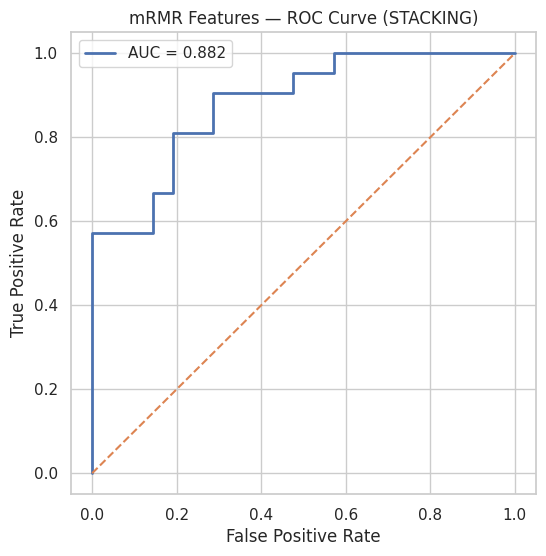

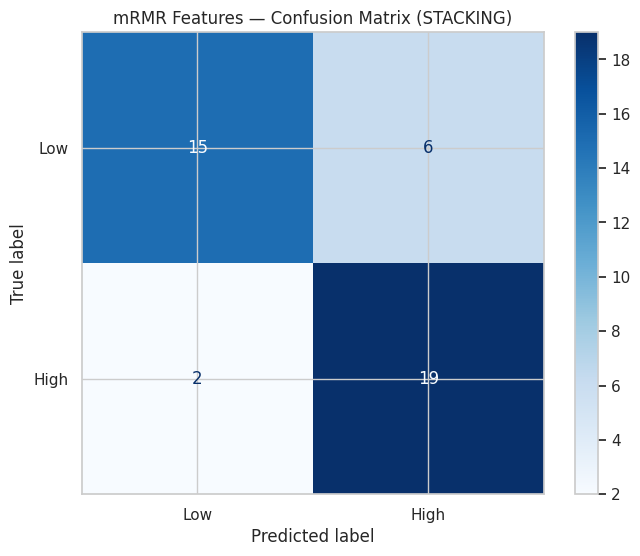


🧪 mRMR Features — STACKING (SVM + XGB → META DNN)
ROC–AUC   : 0.8821
Threshold : 0.36
              precision    recall  f1-score   support

           0     0.8824    0.7143    0.7895        21
           1     0.7600    0.9048    0.8261        21

    accuracy                         0.8095        42
   macro avg     0.8212    0.8095    0.8078        42
weighted avg     0.8212    0.8095    0.8078        42



{'ROC_AUC': np.float64(0.8820861678004535),
 'Accuracy': 0.8095238095238095,
 'Precision': 0.76,
 'Recall': 0.9047619047619048,
 'F1': 0.8260869565217391,
 'Threshold': np.float64(0.36000000000000004),
 'ConfusionMatrix': array([[15,  6],
        [ 2, 19]])}

In [6]:
# =================================================================
# Cell 6 - RUN STACKING (SVM + XGB → META DNN)
# with mRMR Features
# =================================================================

print("\n==============================")
print("🔹 Sel 6 — STACKING + mRMR")
print("==============================")

# Label
y_all = df["label"].values

# Feature matrix (mRMR subset)
X_mrmr = df[features_mrmr].values

# Run stacking pipeline
results_mrmr = run_stacking(
    X=X_mrmr,
    y=y_all,
    feature_name="mRMR Features"
)

results_mrmr



# Cell 7 - RUN STACKING (SVM + XGB → META DNN)
### GA Feature


🔹 Cell 7 - Hybrid–Meta + GA

🔍 GA Selected Features — BASE MODELS (CV tuning)
SVM best CV accuracy : 0.8306
XGB best CV accuracy : 0.8528


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Meta-DNN best CV accuracy : 0.6917


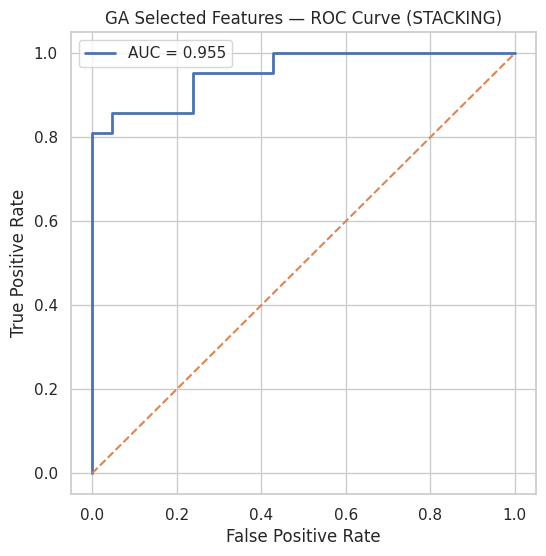

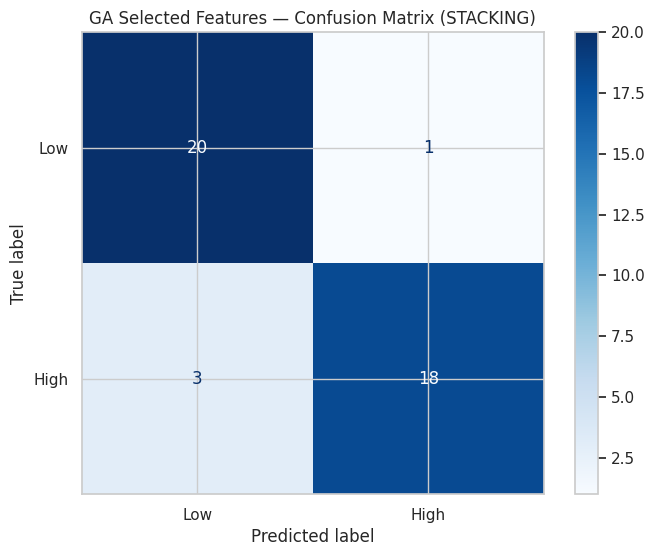


🧪 GA Selected Features — STACKING (SVM + XGB → META DNN)
ROC–AUC   : 0.9546
Threshold : 0.56
              precision    recall  f1-score   support

           0     0.8696    0.9524    0.9091        21
           1     0.9474    0.8571    0.9000        21

    accuracy                         0.9048        42
   macro avg     0.9085    0.9048    0.9045        42
weighted avg     0.9085    0.9048    0.9045        42



{'ROC_AUC': np.float64(0.9546485260770974),
 'Accuracy': 0.9047619047619048,
 'Precision': 0.9473684210526315,
 'Recall': 0.8571428571428571,
 'F1': 0.9,
 'Threshold': np.float64(0.56),
 'ConfusionMatrix': array([[20,  1],
        [ 3, 18]])}

In [7]:
print("\n==============================")
print("🔹 Cell 7 - Hybrid–Meta + GA")
print("==============================")

# ----- LABEL -----
y_all = df["label"].values

# ----- FEATURES -----
X_ga = df[features_ga].values

results_ga = run_stacking(
    X=X_ga,
    y=y_all,
    feature_name="GA Selected Features"
)

results_ga

# Cell 8 - RUN STACKING (SVM + XGB → META DNN)
### L1-LASSO Feature


🔹 Cell 8 - Hybrid–Meta + LASSO

🔍 LASSO Selected Features — BASE MODELS (CV tuning)
SVM best CV accuracy : 0.8556
XGB best CV accuracy : 0.7861


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Meta-DNN best CV accuracy : 0.7083


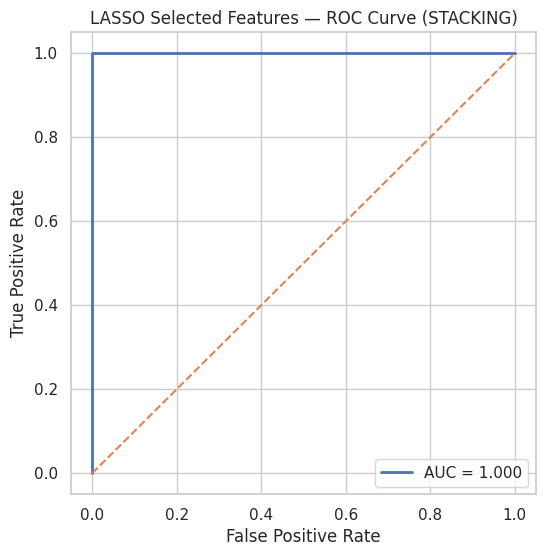

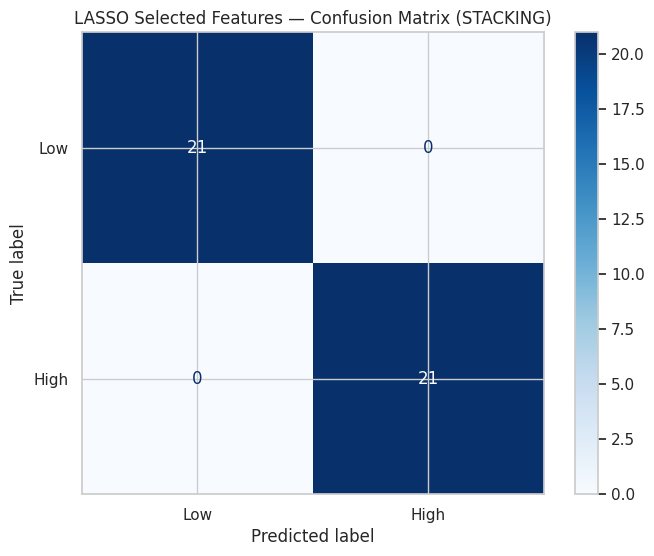


🧪 LASSO Selected Features — STACKING (SVM + XGB → META DNN)
ROC–AUC   : 1.0000
Threshold : 0.07
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        42
   macro avg     1.0000    1.0000    1.0000        42
weighted avg     1.0000    1.0000    1.0000        42



{'ROC_AUC': np.float64(1.0),
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Threshold': np.float64(0.06999999999999999),
 'ConfusionMatrix': array([[21,  0],
        [ 0, 21]])}

In [8]:
print("\n==============================")
print("🔹 Cell 8 - Hybrid–Meta + LASSO")
print("==============================")

# ----- LABEL -----
y_all = df["label"].values

# ----- FEATURES -----
X_lasso = df[features_lasso].values

results_lasso = run_stacking(
    X=X_lasso,
    y=y_all,
    feature_name="LASSO Selected Features"
)

results_lasso


# Cell 9 - RUN STACKING (SVM + XGB → META DNN)
### Full Feature


🔹 Cell 9 - Hybrid–Meta + FULL Features

🔍 Full Radiomics Features — BASE MODELS (CV tuning)
SVM best CV accuracy : 0.6194
XGB best CV accuracy : 1.0000
Meta-DNN best CV accuracy : 1.0000


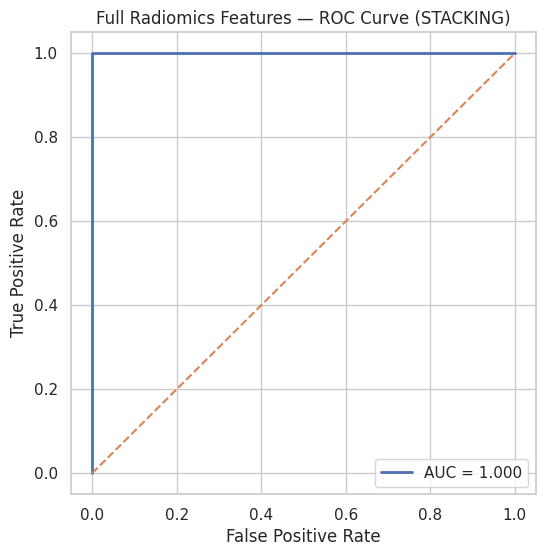

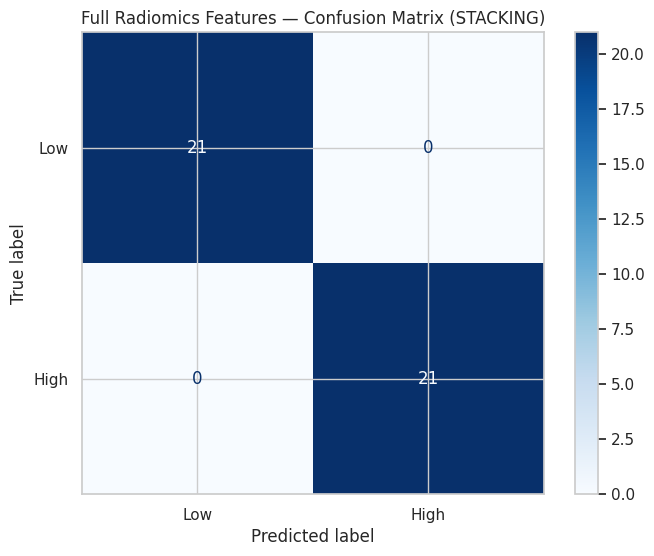


🧪 Full Radiomics Features — STACKING (SVM + XGB → META DNN)
ROC–AUC   : 1.0000
Threshold : 0.02
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        42
   macro avg     1.0000    1.0000    1.0000        42
weighted avg     1.0000    1.0000    1.0000        42



{'ROC_AUC': np.float64(1.0),
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1': 1.0,
 'Threshold': np.float64(0.02),
 'ConfusionMatrix': array([[21,  0],
        [ 0, 21]])}

In [9]:
print("\n==============================")
print("🔹 Cell 9 - Hybrid–Meta + FULL Features")
print("==============================")

# ----- LABEL -----
y_all = df["label"].values

# ----- FEATURES (DROP LABEL COLUMN) -----
X_full = df[features_full].values

results_full = run_stacking(
    X=X_full,
    y=y_all,
    feature_name="Full Radiomics Features"
)

results_full


# Cell 10 - ALL RESULT

In [10]:
import pandas as pd

summary = pd.DataFrame.from_dict({
    "mRMR": results_mrmr,
    "GA": results_ga,
    "LASSO": results_lasso,
    "Full": results_full
}, orient="index")

summary


,ROC_AUC,Accuracy,Precision,Recall,F1,Threshold,ConfusionMatrix
mRMR,0.882086,0.809524,0.760000,0.904762,0.826087,0.36,"[[15, 6], [2, 19]]"
GA,0.954649,0.904762,0.947368,0.857143,0.900000,0.56,"[[20, 1], [3, 18]]"
LASSO,1.000000,1.000000,1.000000,1.000000,1.000000,0.07,"[[21, 0], [0, 21]]"
Full,1.000000,1.000000,1.000000,1.000000,1.000000,0.02,"[[21, 0], [0, 21]]"
